# Convolutional Neural Networks

## Import necessary libraries

In [1]:
from src.models.sequential import Sequential

from src.layers.linear import Linear
from src.layers.activation import Activation
from src.layers.conv2d1c import Conv2d1c
from src.layers.flatten import Flatten
from src.layers.max_pooling import MaxPooling

from src.util.activation_funcs import relu, relu_deriv

from src.util.mnist_load_data_funcs import load_mnist_labels, load_mnist_images
from src.util.mnist_util_funcs import mnist_one_hot_encoder, mnist_score

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

import pathlib

## Get MNIST dataset

In [2]:
BASE_DIR = pathlib.Path(".").resolve()
MNIST_DIR = BASE_DIR / "data"

In [3]:
y_train = load_mnist_labels(MNIST_DIR / "train-labels.idx1-ubyte")
y_test = load_mnist_labels(MNIST_DIR / "t10k-labels.idx1-ubyte")

X_train = load_mnist_images(MNIST_DIR / "train-images.idx3-ubyte")
X_test = load_mnist_images(MNIST_DIR / "t10k-images.idx3-ubyte")

In [4]:
print("X train shape", X_train.shape)
print("X test shape", X_test.shape)
print("")
print("y train shape", y_train.shape)
print("y test shape", y_test.shape)

X train shape (60000, 28, 28)
X test shape (10000, 28, 28)

y train shape (1, 60000)
y test shape (1, 10000)


Random indices [ 5355 46437 39274]
Label 1
Label 1
Label 5


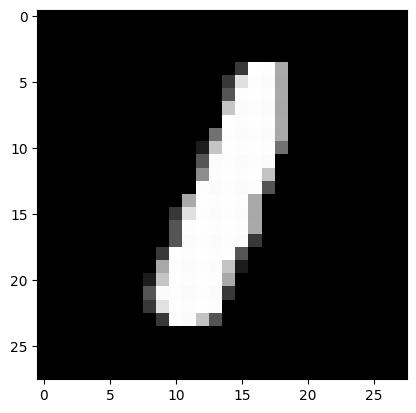

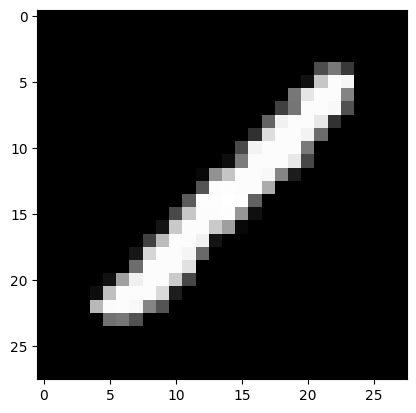

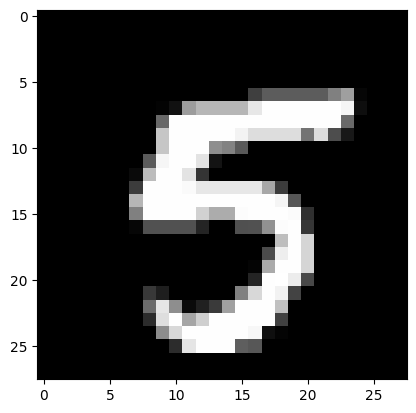

In [5]:
peek_at_mnist_size = 3

rng = np.random.default_rng(seed=42)
train_indices = rng.integers(low=0, high=X_train.shape[0], size=peek_at_mnist_size)

print("Random indices", train_indices)
for idx in train_indices:
    plt.figure()

    print("Label", y_train[0, idx])

    plt.imshow(X_train[idx, :, :], cmap="gray")

Random indices [ 892 7739 6545]
Label 2
Label 2
Label 1


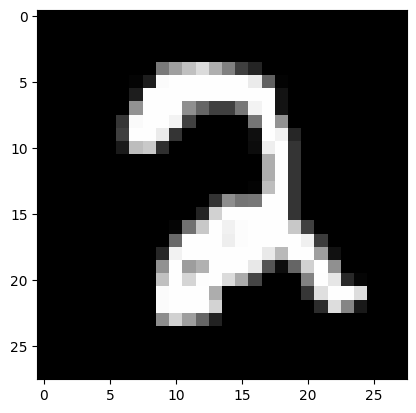

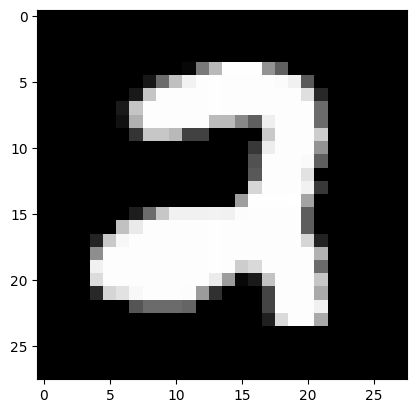

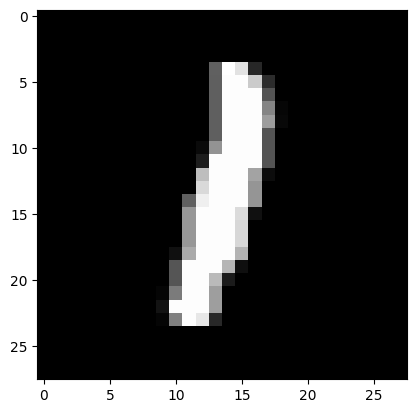

In [6]:
peek_at_mnist_size = 3

rng = np.random.default_rng(seed=42)
test_indices = rng.integers(low=0, high=X_test.shape[0], size=peek_at_mnist_size)

print("Random indices", test_indices)
for idx in test_indices:
    plt.figure()

    print("Label", y_test[0, idx])

    plt.imshow(X_test[idx, :, :], cmap="gray")

## Encode target

In [7]:
y_train = mnist_one_hot_encoder(y_train)
y_test = mnist_one_hot_encoder(y_test)

In [8]:
print("Encoded training target")
for idx in train_indices:
    print(y_train[:, idx])

Encoded training target
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [9]:
print("Encoded test target")
for idx in test_indices:
    print(y_test[:, idx])

Encoded test target
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## Initialize models

### Initialize MLFun CNN

In [10]:
model_mlfun = Sequential(
    [
        Conv2d1c(16, (3, 3)),
        Activation((relu, relu_deriv)),
        MaxPooling((2, 2), strides=(2, 2)),
        Flatten(),
        Linear((10, 2704)),
    ]
)

### Initialize TensorFlow model

In [11]:
model_tf = keras.Sequential(
    [
        layers.Conv2D(16, (3, 3)),
        layers.Activation("relu"),
        layers.MaxPool2D((2, 2), strides=(2, 2)),
        layers.Flatten(),
        layers.Dense(10),
    ]
)

## Train models

In [12]:
training_data_size = 1000
learning_rate = 0.01
number_epochs = 50
batch_size = 8

### Train MLFun model

In [13]:
%%time
model_mlfun.fit(
    X_train[:training_data_size],
    y_train[:, :training_data_size],
    learning_rate,
    number_epochs,
    score=mnist_score,
    batch_size=batch_size,
)

Epoch 0, accuracy: 0.109
Epoch 1, accuracy: 0.13
Epoch 2, accuracy: 0.129
Epoch 3, accuracy: 0.141
Epoch 4, accuracy: 0.153
Epoch 5, accuracy: 0.178
Epoch 6, accuracy: 0.183
Epoch 7, accuracy: 0.181
Epoch 8, accuracy: 0.192
Epoch 9, accuracy: 0.215
Epoch 10, accuracy: 0.213
Epoch 11, accuracy: 0.26
Epoch 12, accuracy: 0.245
Epoch 13, accuracy: 0.258
Epoch 14, accuracy: 0.258
Epoch 15, accuracy: 0.297
Epoch 16, accuracy: 0.313
Epoch 17, accuracy: 0.343
Epoch 18, accuracy: 0.366
Epoch 19, accuracy: 0.382
Epoch 20, accuracy: 0.391
Epoch 21, accuracy: 0.401
Epoch 22, accuracy: 0.425
Epoch 23, accuracy: 0.429
Epoch 24, accuracy: 0.435
Epoch 25, accuracy: 0.436
Epoch 26, accuracy: 0.466
Epoch 27, accuracy: 0.474
Epoch 28, accuracy: 0.498
Epoch 29, accuracy: 0.537
Epoch 30, accuracy: 0.547
Epoch 31, accuracy: 0.552
Epoch 32, accuracy: 0.572
Epoch 33, accuracy: 0.571
Epoch 34, accuracy: 0.61
Epoch 35, accuracy: 0.599
Epoch 36, accuracy: 0.612
Epoch 37, accuracy: 0.605
Epoch 38, accuracy: 0.654

### Train TensorFlow model

#### Change shape of the data

In [14]:
X_train_tf = X_train.reshape((-1, 28, 28, 1))
X_test_tf = X_test.reshape((-1, 28, 28, 1))

y_train_tf = y_train.T
y_test_tf = y_test.T

In [15]:
print(X_train_tf[:training_data_size, :, :].shape)
print(y_train_tf[:training_data_size, :].shape)

(1000, 28, 28, 1)
(1000, 10)


#### Train model

In [16]:
%%time
model_tf.compile(
    optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
    loss=keras.losses.MeanSquaredError,
)

model_tf.fit(
    X_train_tf[:training_data_size, :, :],
    y_train_tf[:training_data_size, :],
    batch_size=batch_size,
    epochs=number_epochs,
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0954
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0827
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0753
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0689
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0636
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0593
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0559
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0533
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0512
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0494
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0480
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0467
Epoch 13/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0456
Epoch 14/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0446
Epoch 15/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

## Compare models

### MLFun

In [18]:
pred_mlfun = model_mlfun.predict(X_test)

In [19]:
print(f"Accuracy: {mnist_score(pred_mlfun, y_test)}")

Accuracy: 0.6136


### TensorFlow

In [20]:
pred_tf = model_tf.predict(X_test_tf).T

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [21]:
print(f"Accuracy: {mnist_score(pred_tf, y_test)}")

Accuracy: 0.87
